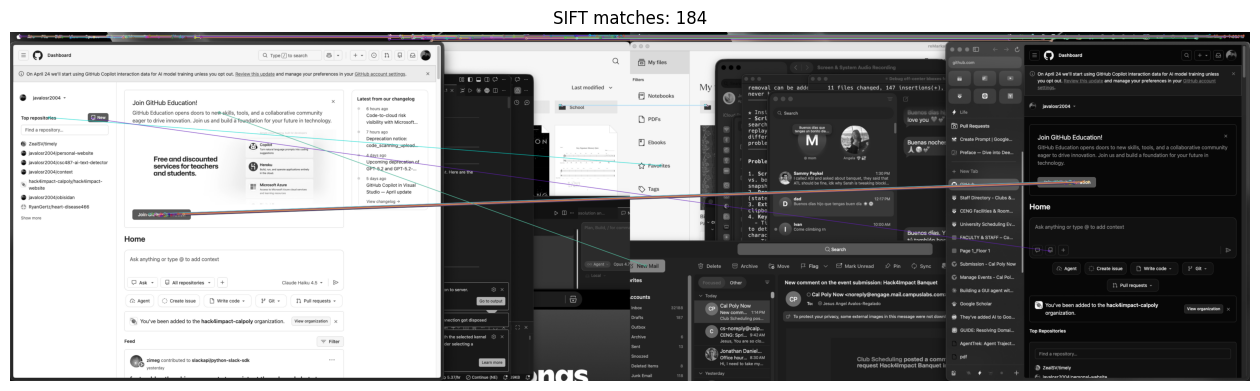

In [4]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt


image_a_path = Path("github_light.png")
image_b_path = Path("github_dark.png")

if not image_a_path.exists():
    image_a_path = Path("notebooks/github_light.png")
if not image_b_path.exists():
    image_b_path = Path("notebooks/github_dark.png")

image_a = cv2.imread(str(image_a_path), cv2.IMREAD_GRAYSCALE)
image_b = cv2.imread(str(image_b_path), cv2.IMREAD_GRAYSCALE)

if image_a is None or image_b is None:
    raise FileNotFoundError("Could not load image_a or image_b. Check the paths above.")

sift = cv2.SIFT_create()
keypoints_a, descriptors_a = sift.detectAndCompute(image_a, None)
keypoints_b, descriptors_b = sift.detectAndCompute(image_b, None)

matcher = cv2.BFMatcher()
raw_matches = matcher.knnMatch(descriptors_a, descriptors_b, k=2)

good_matches = []
for best, second_best in raw_matches:
    if best.distance < 0.3 * second_best.distance:
        good_matches.append(best)

matched_image = cv2.drawMatches(
    image_a,
    keypoints_a,
    image_b,
    keypoints_b,
    good_matches,
    None,
    flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS,
)

plt.figure(figsize=(16, 8))
plt.imshow(matched_image, cmap="gray")
plt.title(f"SIFT matches: {len(good_matches)}")
plt.axis("off")
plt.show()
